In [1]:
include("functions.jl")

using Pkg
Pkg.precompile()

using Plots, JLD2, LaTeXStrings, FileIO

In [2]:
@load "/home/agfleischhauer/roq68sum/rydberg_qec/codework/shor_code_data/driving_abc_parallel/N_atoms=9_γ_decay=0.001_Ntraj=100.jld2"

ψ = ψ
a1 = population_a
a2 = population_c
a3 = population_ac;
time_taken = execution_time

181.45524907112122

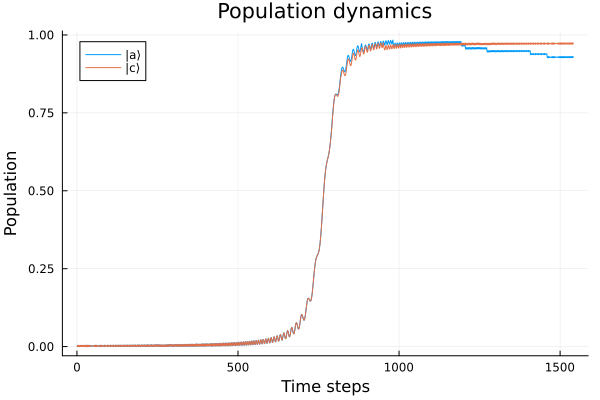

In [3]:
plot(a1, label="|a⟩", xlabel="Time steps", ylabel="Population", title="Population dynamics")
plot!(a2, label="|c⟩")
# plot!(a3, label="|a⟩, |c⟩")

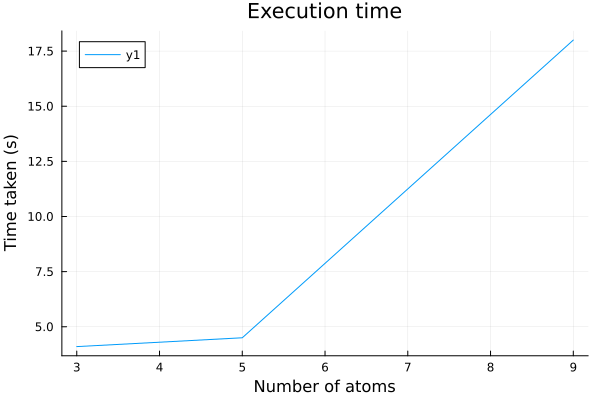

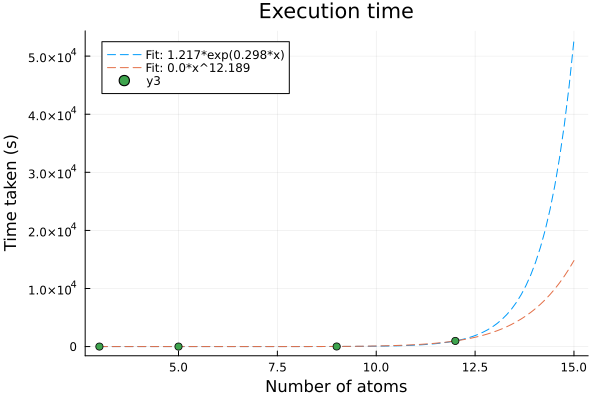

In [38]:
using LsqFit, Plots

sys = [3,5,9,12]
time_taken = [4.1, 4.5, 18.0, 976.0]

exponential(x, p) = p[1] .* exp.(p[2] .* x)
power_law(x, p) = p[1] .* x .^ p[2]
p0_exp = [1.0, 0.1]
p0_power = [1.0, 1.0]

exp_fit = curve_fit(exponential, sys, time_taken, p0_exp)
power_fit = curve_fit(power_law, sys, time_taken, p0_power)

a1 = trunc(exp_fit.param[1],digits=3)
b1 = trunc(exp_fit.param[2],digits=3)

a2 = trunc(power_fit.param[1],digits=5)
b2 = trunc(power_fit.param[2],digits=3)

x_vals = range(minimum(sys), 15, length=100)

fitted_y1_vals = exponential(x_vals, exp_fit.param)
fitted_y2_vals = power_law(x_vals, power_fit.param)

plot(x_vals, fitted_y1_vals, linestyle=:dash, label="Fit: $(a)*exp($(b)*x)")
plot!(x_vals, fitted_y2_vals, linestyle=:dash, label="Fit: $(a2)*x^$(b2)")
scatter!(sys, time_taken, xlabel="Number of atoms", ylabel="Time taken (s)", title="Execution time")

In [42]:
fitted_y1_vals[end]/(60*60)

14.655802759870356